
RUNNING OPTIMIZED PIPELINE (EDA-BASED)

OPTIMIZED ML PIPELINE (EDA-DRIVEN)
Configuration:
  • Feature Selection: True
  • PCA: False
  • SMOTE: False

📂 Loading dataset...
   ✅ Loaded: 1749 rows, 21 columns
   ✅ Original class distribution: {0: 1446, 1: 303}
   ✅ Imbalance ratio: 4.77:1

🔍 Removing multicollinear features (threshold=0.85)...
   Dropping features: ['rfc', 'ca', 'loc']
   Retained features: 17/20

📊 Applying log transformation to skewed features...
   ✓ Transformed: lcom
   ✓ Transformed: cbo
   ✓ Transformed: cbm
   ✓ Transformed: npm
   ✓ Transformed: ce

⭐ Selecting top 12 features...
   Selected features:
    1. amc        (importance: 0.1062)
    2. avg_cc     (importance: 0.0918)
    3. cam        (importance: 0.0815)
    4. cbo        (importance: 0.0812)
    5. lcom       (importance: 0.0779)
    6. wmc        (importance: 0.0767)
    7. ce         (importance: 0.0751)
    8. max_cc     (importance: 0.0728)
    9. lcom3      (importance: 0.0725)
   10. npm      

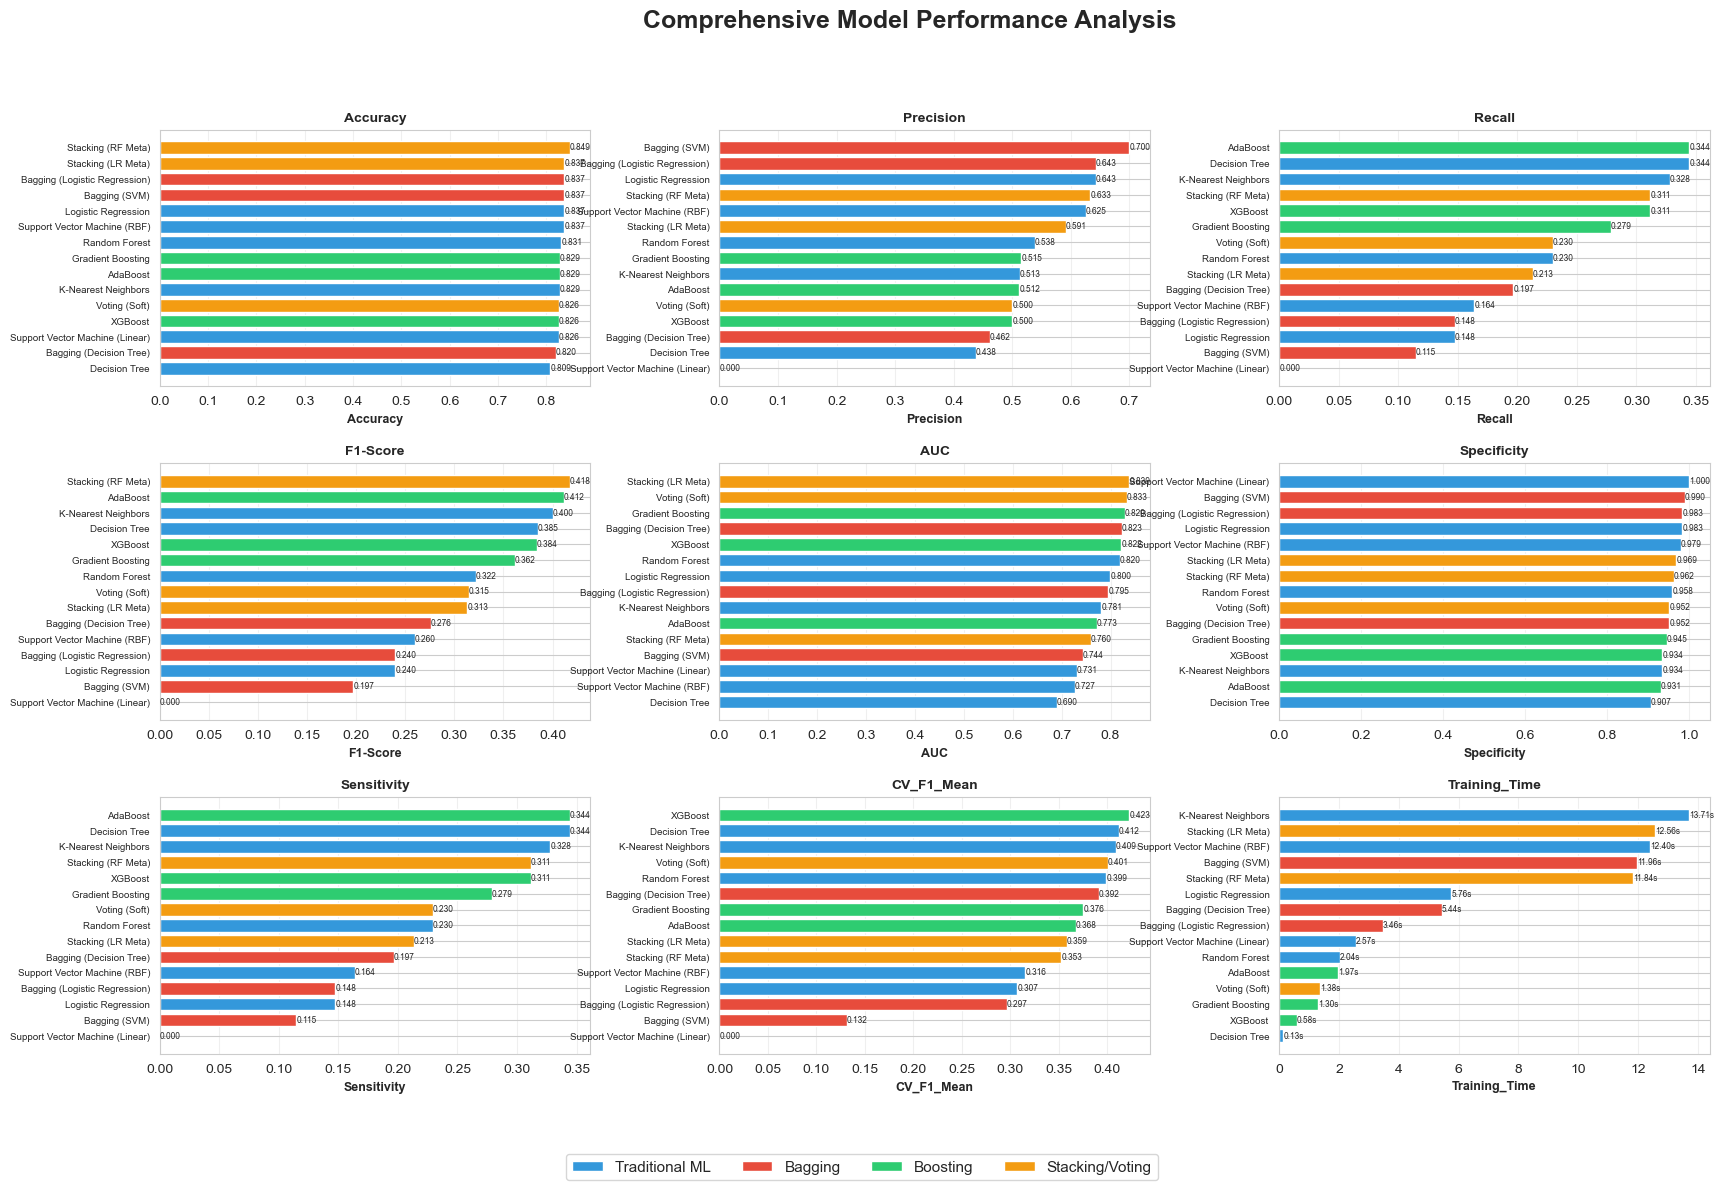

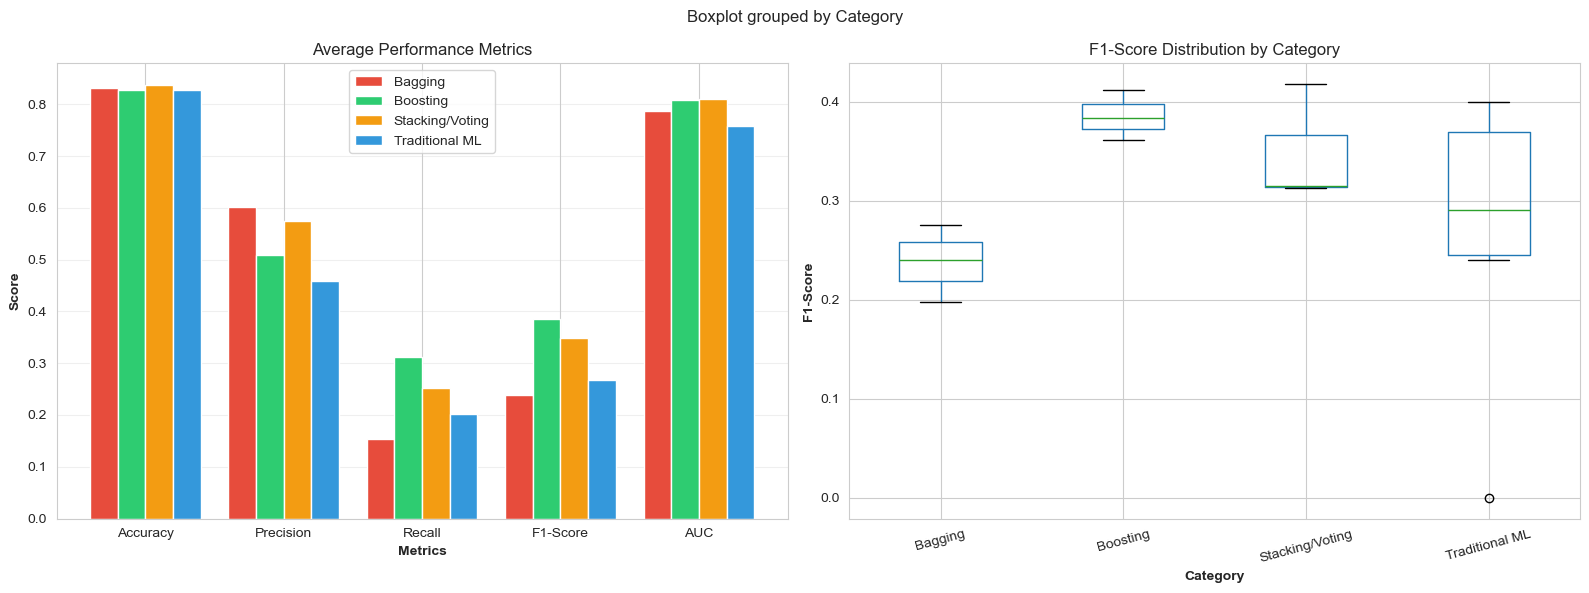

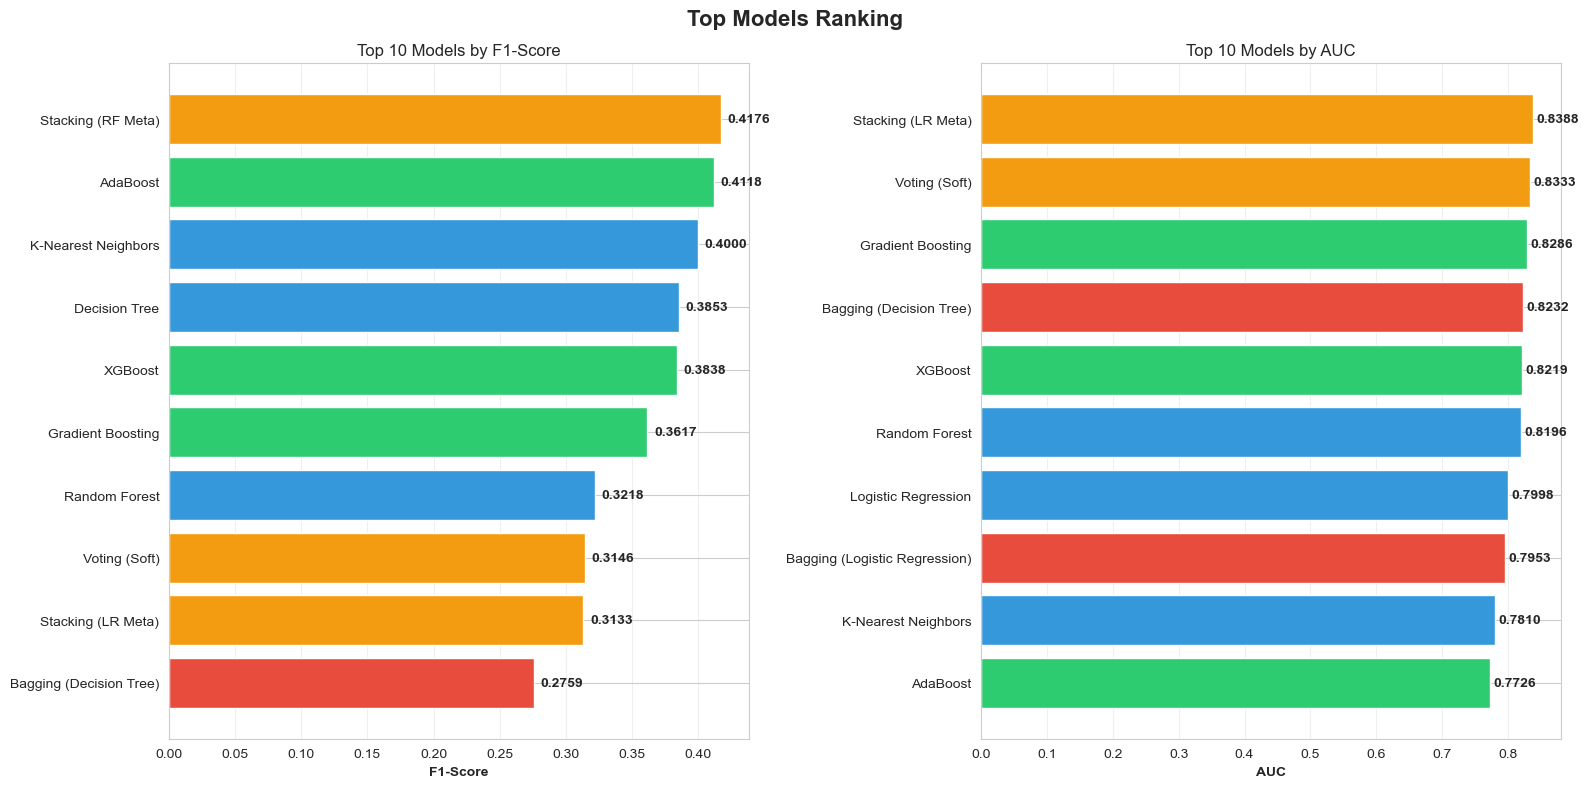

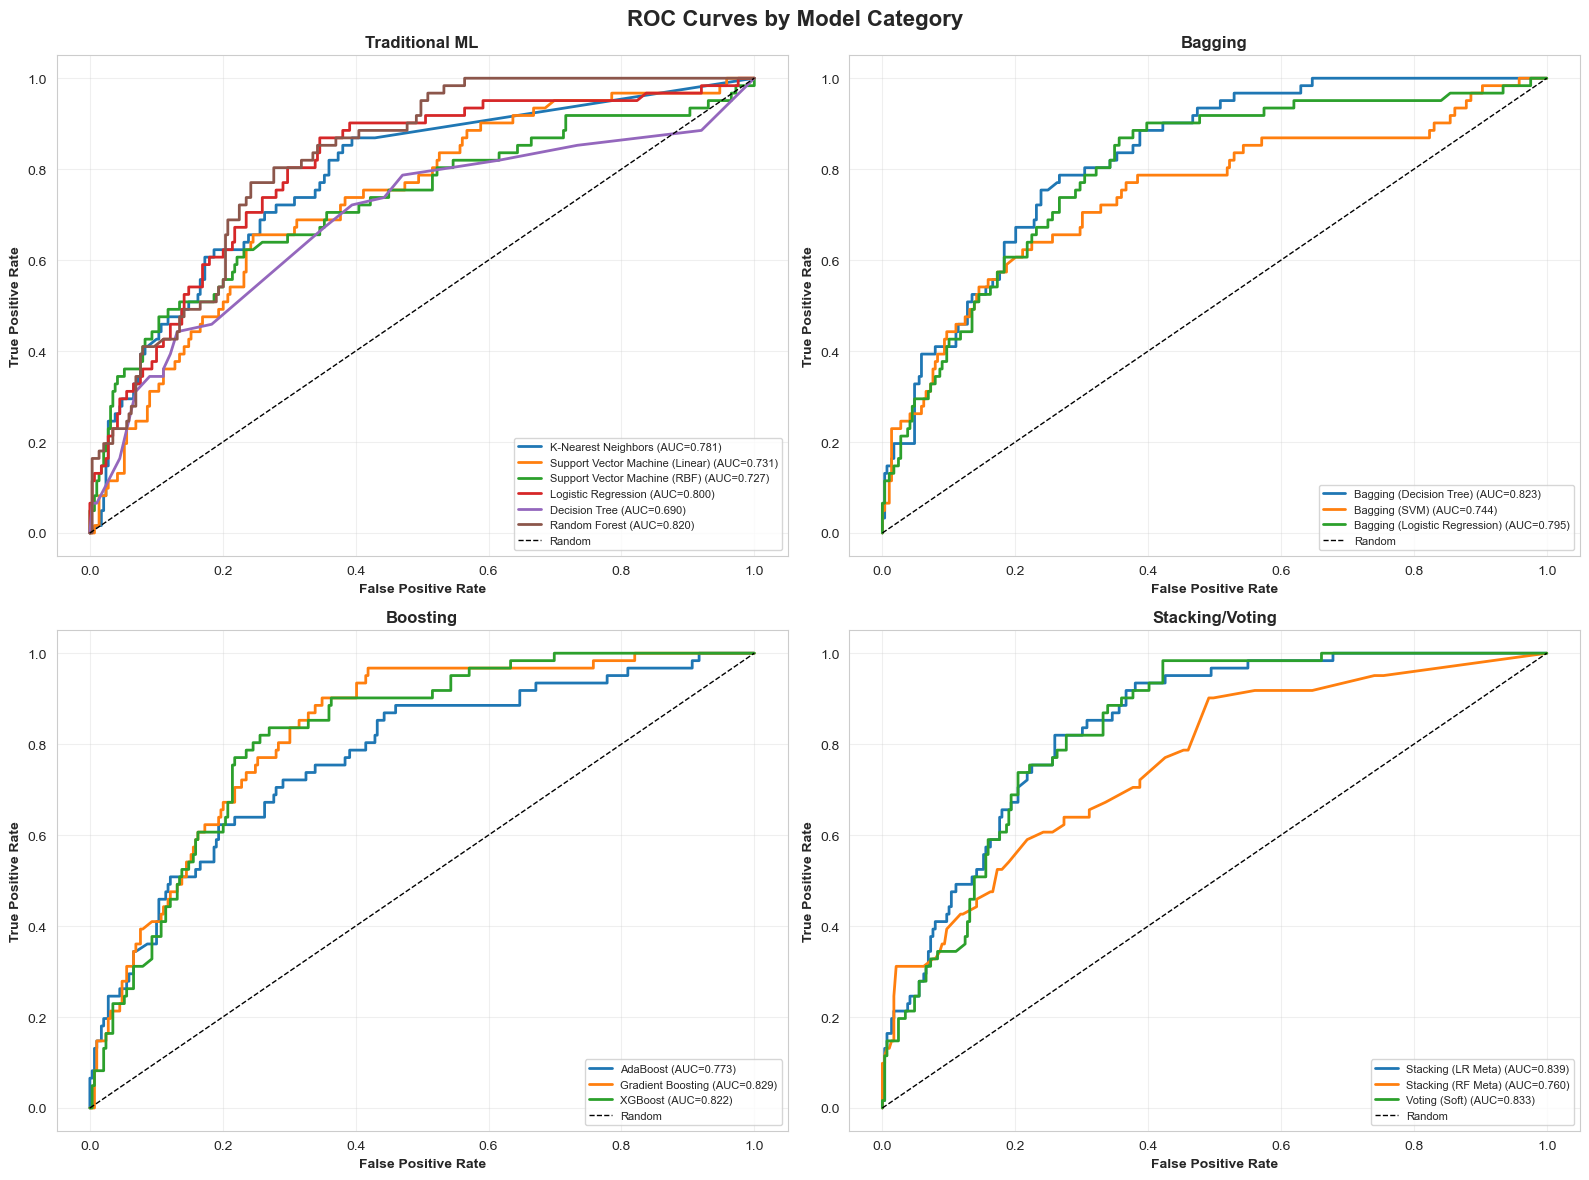

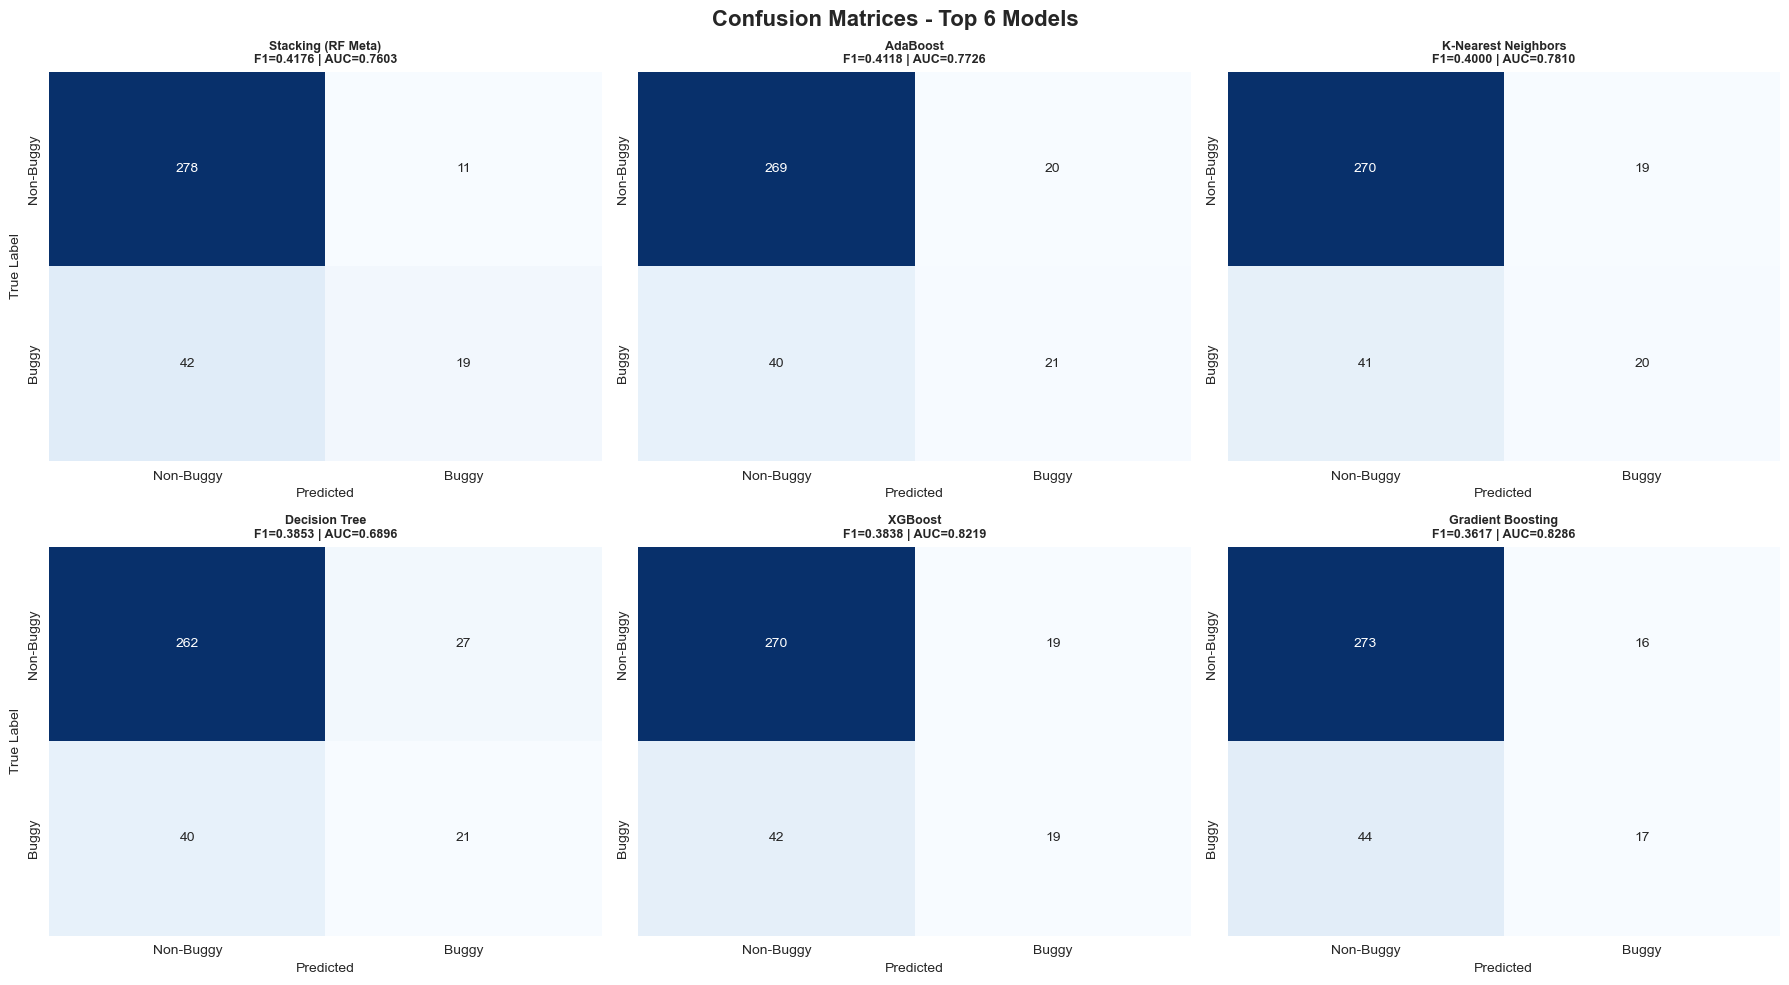


STATISTICAL ANALYSIS & INSIGHTS

🏆 BEST MODELS PER METRIC:
────────────────────────────────────────────────────────────────────────────────

Accuracy:
   Model: Stacking (RF Meta)
   Category: Stacking/Voting
   Score: 0.8486
   CV F1: 0.3528 (±0.0631)

Precision:
   Model: Bagging (SVM)
   Category: Bagging
   Score: 0.7000
   CV F1: 0.1316 (±0.0410)

Recall:
   Model: Decision Tree
   Category: Traditional ML
   Score: 0.3443
   CV F1: 0.4125 (±0.0335)

F1-Score:
   Model: Stacking (RF Meta)
   Category: Stacking/Voting
   Score: 0.4176
   CV F1: 0.3528 (±0.0631)

AUC:
   Model: Stacking (LR Meta)
   Category: Stacking/Voting
   Score: 0.8388
   CV F1: 0.3586 (±0.0458)

Specificity:
   Model: Support Vector Machine (Linear)
   Category: Traditional ML
   Score: 1.0000
   CV F1: 0.0000 (±0.0000)

Sensitivity:
   Model: Decision Tree
   Category: Traditional ML
   Score: 0.3443
   CV F1: 0.4125 (±0.0335)


📊 CATEGORY-WISE STATISTICS:
───────────────────────────────────────────────────

  File "C:\Users\sodhi\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\sodhi\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sodhi\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\sodhi\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


   Selected features:
    1. dam        (importance: 0.1142)
    2. lcom       (importance: 0.0920)
    3. ce         (importance: 0.0879)
    4. cbo        (importance: 0.0831)
    5. avg_cc     (importance: 0.0792)
    6. lcom3      (importance: 0.0782)
    7. wmc        (importance: 0.0772)
    8. amc        (importance: 0.0757)
    9. npm        (importance: 0.0570)
   10. max_cc     (importance: 0.0523)
   11. cam        (importance: 0.0510)
   12. mfa        (importance: 0.0426)

⚙️  Scaling features with RobustScaler (handles outliers)...

✅ Final dataset:
   • Training set: 2255 samples × 12 features
   • Test set: 564 samples × 12 features
   • Train class dist: {0: 1157, 1: 1098}
   • Test class dist: {0: 289, 1: 275}

STRATEGY COMPARISON (Random Forest)

                  Strategy  F1-Score      AUC  Accuracy  Features
Baseline (No Optimization)  0.343434 0.803421  0.814286        17
    Feature Selection Only  0.336842 0.815872  0.820000        12
                  PCA Only

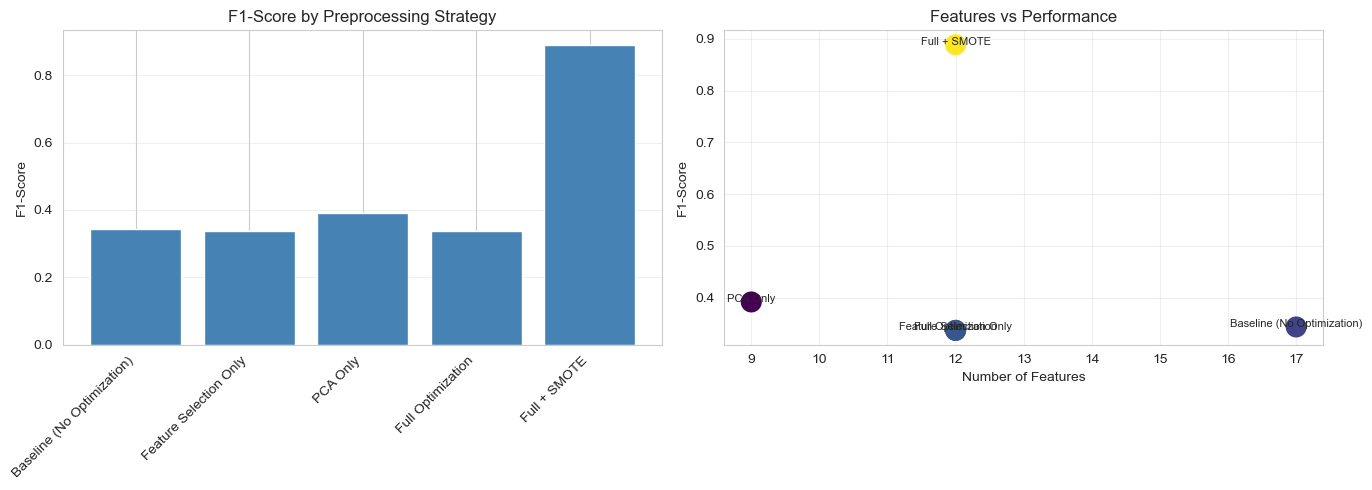

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, auc, make_scorer
)

# Traditional ML Models
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Ensemble Methods
from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
    VotingClassifier
)
from xgboost import XGBClassifier

# Imbalanced learning (optional based on strategy)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

import time
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)


class OptimizedMLPipeline:
    """
    Optimized ML Pipeline incorporating EDA insights:
    - Feature selection (top 12 features)
    - Multicollinearity handling
    - Log transformation for skewed features
    - RobustScaler for outliers
    - Optional SMOTE (light resampling)
    - PCA variant for comparison
    """
    
    def __init__(self, file_path, target_column='bug', test_size=0.2, random_state=42,
                 use_feature_selection=True, use_pca=False, use_smote=False):
        """
        Initialize optimized pipeline
        
        Parameters:
        -----------
        file_path : str
            Path to CSV file
        target_column : str
            Target column name
        test_size : float
            Test set ratio
        random_state : int
            Random seed
        use_feature_selection : bool
            Apply feature importance-based selection
        use_pca : bool
            Use PCA for dimensionality reduction
        use_smote : bool
            Apply SMOTE for class balancing (optional)
        """
        self.file_path = file_path
        self.target_column = target_column
        self.test_size = test_size
        self.random_state = random_state
        self.use_feature_selection = use_feature_selection
        self.use_pca = use_pca
        self.use_smote = use_smote
        
        self.df = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.scaler = None
        self.feature_selector = None
        self.pca_model = None
        self.selected_features = None
        
        self.results = []
        self.trained_models = {}
        self.predictions = {}
        
        print(f"\n{'='*80}")
        print(f"OPTIMIZED ML PIPELINE (EDA-DRIVEN)")
        print(f"{'='*80}")
        print(f"Configuration:")
        print(f"  • Feature Selection: {use_feature_selection}")
        print(f"  • PCA: {use_pca}")
        print(f"  • SMOTE: {use_smote}")
        print(f"{'='*80}\n")
        
        self._load_and_prepare_data()
    
    def _remove_multicollinear_features(self, X, threshold=0.85):
        """
        Remove one feature from highly correlated pairs
        Based on EDA: cbo&ca, rfc&loc, max_cc&avg_cc, wmc&rfc, dit&mfa, wmc&npm
        """
        print(f"\n🔍 Removing multicollinear features (threshold={threshold})...")
        
        # Calculate correlation matrix
        corr_matrix = X.corr().abs()
        
        # Find upper triangle
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        
        # Find features with correlation > threshold
        to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
        
        print(f"   Dropping features: {to_drop}")
        print(f"   Retained features: {X.shape[1] - len(to_drop)}/{X.shape[1]}")
        
        return X.drop(columns=to_drop), to_drop
    
    def _apply_log_transformation(self, X, skewed_features):
        """
        Apply log transformation to highly skewed features
        Based on EDA: lcom, ca, cbo, cbm, npm
        """
        print(f"\n📊 Applying log transformation to skewed features...")
        X_transformed = X.copy()
        
        for feature in skewed_features:
            if feature in X_transformed.columns:
                # Add 1 to avoid log(0)
                X_transformed[feature] = np.log1p(X_transformed[feature])
                print(f"   ✓ Transformed: {feature}")
        
        return X_transformed
    
    def _select_top_features(self, X, y, n_features=12):
        """
        Select top features based on Random Forest importance
        Based on EDA: top 12 features explain 80% importance
        """
        print(f"\n⭐ Selecting top {n_features} features...")
        
        # Train RF for feature importance
        rf = RandomForestClassifier(n_estimators=100, random_state=self.random_state, n_jobs=-1)
        rf.fit(X, y)
        
        # Get feature importances
        importance_df = pd.DataFrame({
            'feature': X.columns,
            'importance': rf.feature_importances_
        }).sort_values('importance', ascending=False)
        
        self.selected_features = importance_df.head(n_features)['feature'].tolist()
        
        print(f"   Selected features:")
        for i, (feat, imp) in enumerate(zip(self.selected_features, 
                                            importance_df.head(n_features)['importance']), 1):
            print(f"   {i:2d}. {feat:10s} (importance: {imp:.4f})")
        
        return X[self.selected_features]
    
    def _load_and_prepare_data(self):
        """Load and preprocess data with EDA-based optimizations"""
        print("📂 Loading dataset...")
        self.df = pd.read_csv(self.file_path)
        
        # Binary target conversion
        self.df[self.target_column] = self.df[self.target_column].apply(
            lambda x: 0 if x == 0 else 1
        )
        
        print(f"   ✅ Loaded: {self.df.shape[0]} rows, {self.df.shape[1]} columns")
        
        X = self.df.drop(columns=[self.target_column])
        y = self.df[self.target_column]
        
        original_class_dist = dict(y.value_counts())
        print(f"   ✅ Original class distribution: {original_class_dist}")
        print(f"   ✅ Imbalance ratio: {max(original_class_dist.values())/min(original_class_dist.values()):.2f}:1")
        
        # Step 1: Remove multicollinear features
        X, dropped_features = self._remove_multicollinear_features(X, threshold=0.85)
        
        # Step 2: Apply log transformation to skewed features
        skewed_features = ['lcom', 'ca', 'cbo', 'cbm', 'npm', 'rfc', 'ce']
        skewed_features = [f for f in skewed_features if f in X.columns]
        X = self._apply_log_transformation(X, skewed_features)
        
        # Step 3: Optional SMOTE (light resampling)
        if self.use_smote:
            # Calculate current ratio
            class_counts = pd.Series(y).value_counts()
            minority_class = class_counts.idxmin()
            majority_class = class_counts.idxmax()
            current_ratio = class_counts[minority_class] / class_counts[majority_class]
            
            # Only apply SMOTE if it makes sense (current ratio < 0.9)
            if current_ratio < 0.9:
                target_ratio = 0.95  # Bring minority to 95% of majority
                print(f"\n🔄 Applying SMOTE (strategy={target_ratio})...")
                print(f"   Current ratio: {current_ratio:.2f}")
                smote = SMOTE(sampling_strategy=target_ratio, random_state=self.random_state)
                X, y = smote.fit_resample(X, y)
                print(f"   ✅ After SMOTE: {dict(pd.Series(y).value_counts())}")
            else:
                print(f"\n✓ Classes already balanced ({current_ratio:.2f}), skipping SMOTE")
        
        # Step 4: Feature selection (top 12 features)
        if self.use_feature_selection:
            X = self._select_top_features(X, y, n_features=12)
        
        # Step 5: Train-test split
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, 
            test_size=self.test_size, 
            stratify=y,
            random_state=self.random_state
        )
        
        print(f"\n⚙️  Scaling features with RobustScaler (handles outliers)...")
        self.scaler = RobustScaler()
        self.X_train = self.scaler.fit_transform(self.X_train)
        self.X_test = self.scaler.transform(self.X_test)
        
        # Step 6: Optional PCA
        if self.use_pca:
            print(f"\n🎨 Applying PCA (95% variance)...")
            self.pca_model = PCA(n_components=0.95, random_state=self.random_state)
            self.X_train = self.pca_model.fit_transform(self.X_train)
            self.X_test = self.pca_model.transform(self.X_test)
            print(f"   ✅ PCA components: {self.pca_model.n_components_}")
            print(f"   ✅ Explained variance: {self.pca_model.explained_variance_ratio_.sum():.1%}")
        
        print(f"\n✅ Final dataset:")
        print(f"   • Training set: {self.X_train.shape[0]} samples × {self.X_train.shape[1]} features")
        print(f"   • Test set: {self.X_test.shape[0]} samples × {self.X_test.shape[1]} features")
        print(f"   • Train class dist: {dict(pd.Series(self.y_train).value_counts())}")
        print(f"   • Test class dist: {dict(pd.Series(self.y_test).value_counts())}")
    
    def _evaluate_model(self, name, model, category):
        """Evaluate model with comprehensive metrics"""
        print(f"\n🔹 Training {name}...")
        start_time = time.time()
        
        # Cross-validation F1 score
        cv_scores = cross_val_score(model, self.X_train, self.y_train, 
                                    cv=5, scoring='f1', n_jobs=-1)
        cv_f1_mean = cv_scores.mean()
        cv_f1_std = cv_scores.std()
        
        # Train model
        model.fit(self.X_train, self.y_train)
        training_time = time.time() - start_time
        
        # Predictions
        y_pred = model.predict(self.X_test)
        y_prob = model.predict_proba(self.X_test)[:, 1] if hasattr(model, 'predict_proba') else None
        
        # Store predictions
        self.predictions[name] = {'y_pred': y_pred, 'y_prob': y_prob}
        self.trained_models[name] = model
        
        # Calculate metrics
        metrics = {
            'Model': name,
            'Category': category,
            'CV_F1_Mean': cv_f1_mean,
            'CV_F1_Std': cv_f1_std,
            'Accuracy': accuracy_score(self.y_test, y_pred),
            'Precision': precision_score(self.y_test, y_pred, zero_division=0),
            'Recall': recall_score(self.y_test, y_pred, zero_division=0),
            'F1-Score': f1_score(self.y_test, y_pred, zero_division=0),
            'AUC': roc_auc_score(self.y_test, y_prob) if y_prob is not None else np.nan,
            'Training_Time': training_time
        }
        
        # Confusion matrix
        cm = confusion_matrix(self.y_test, y_pred)
        metrics['TN'] = cm[0, 0]
        metrics['FP'] = cm[0, 1]
        metrics['FN'] = cm[1, 0]
        metrics['TP'] = cm[1, 1]
        
        # Calculate specificity and sensitivity
        metrics['Specificity'] = cm[0, 0] / (cm[0, 0] + cm[0, 1]) if (cm[0, 0] + cm[0, 1]) > 0 else 0
        metrics['Sensitivity'] = cm[1, 1] / (cm[1, 1] + cm[1, 0]) if (cm[1, 1] + cm[1, 0]) > 0 else 0
        
        self.results.append(metrics)
        
        print(f"   ✅ CV F1: {cv_f1_mean:.4f} (±{cv_f1_std:.4f})")
        print(f"   ✅ Test F1: {metrics['F1-Score']:.4f} | AUC: {metrics['AUC']:.4f} | Time: {training_time:.2f}s")
        
        return metrics
    
    # =====================================================
    # MODEL TRAINING METHODS
    # =====================================================
    
    def run_traditional_models(self):
        """Train traditional ML models with optimized hyperparameters"""
        print(f"\n{'='*80}")
        print("PART 1: TRADITIONAL ML MODELS")
        print(f"{'='*80}")
        
        models = {
            'K-Nearest Neighbors': KNeighborsClassifier(
                n_neighbors=7,
                weights='distance',
                metric='minkowski',
                p=2
            ),
            'Support Vector Machine (Linear)': SVC(
                C=1.0,
                kernel='linear',
                probability=True,
                random_state=self.random_state
            ),
            'Support Vector Machine (RBF)': SVC(
                C=10.0,
                kernel='rbf',
                gamma='scale',
                probability=True,
                random_state=self.random_state
            ),
            'Logistic Regression': LogisticRegression(
                C=1.0,
                penalty='l2',
                solver='lbfgs',
                max_iter=1000,
                random_state=self.random_state
            ),
            'Decision Tree': DecisionTreeClassifier(
                max_depth=6,
                min_samples_split=10,
                min_samples_leaf=4,
                criterion='gini',
                random_state=self.random_state
            ),
            'Random Forest': RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                min_samples_split=5,
                min_samples_leaf=2,
                max_features='sqrt',
                random_state=self.random_state,
                n_jobs=-1
            )
        }
        
        for name, model in models.items():
            self._evaluate_model(name, model, 'Traditional ML')
    
    def run_bagging_models(self):
        """Train bagging ensemble models"""
        print(f"\n{'='*80}")
        print("PART 2: BAGGING ENSEMBLE")
        print(f"{'='*80}")
        
        models = {
            'Bagging (Decision Tree)': BaggingClassifier(
                estimator=DecisionTreeClassifier(max_depth=6, random_state=self.random_state),
                n_estimators=100,
                max_samples=0.8,
                max_features=0.8,
                bootstrap=True,
                random_state=self.random_state,
                n_jobs=-1
            ),
            'Bagging (SVM)': BaggingClassifier(
                estimator=SVC(probability=True, kernel='rbf', random_state=self.random_state),
                n_estimators=50,
                max_samples=0.7,
                bootstrap=True,
                random_state=self.random_state,
                n_jobs=-1
            ),
            'Bagging (Logistic Regression)': BaggingClassifier(
                estimator=LogisticRegression(random_state=self.random_state),
                n_estimators=50,
                max_samples=0.8,
                bootstrap=True,
                random_state=self.random_state,
                n_jobs=-1
            )
        }
        
        for name, model in models.items():
            self._evaluate_model(name, model, 'Bagging')
    
    def run_boosting_models(self):
        """Train boosting ensemble models"""
        print(f"\n{'='*80}")
        print("PART 3: BOOSTING ENSEMBLE")
        print(f"{'='*80}")
        
        models = {
            'AdaBoost': AdaBoostClassifier(
                estimator=DecisionTreeClassifier(max_depth=3),
                n_estimators=100,
                learning_rate=1.0,
                random_state=self.random_state
            ),
            'Gradient Boosting': GradientBoostingClassifier(
                n_estimators=150,
                learning_rate=0.1,
                max_depth=5,
                min_samples_split=10,
                min_samples_leaf=4,
                subsample=0.8,
                max_features='sqrt',
                random_state=self.random_state
            ),
            'XGBoost': XGBClassifier(
                n_estimators=150,
                learning_rate=0.1,
                max_depth=6,
                min_child_weight=3,
                subsample=0.8,
                colsample_bytree=0.8,
                gamma=0.1,
                reg_alpha=0.1,
                reg_lambda=1.0,
                random_state=self.random_state,
                eval_metric='logloss',
                use_label_encoder=False,
                n_jobs=-1
            )
        }
        
        for name, model in models.items():
            self._evaluate_model(name, model, 'Boosting')
    
    def run_stacking_voting_models(self):
        """Train stacking and voting ensemble models"""
        print(f"\n{'='*80}")
        print("PART 4: STACKING & VOTING ENSEMBLE")
        print(f"{'='*80}")
        
        # Base estimators
        base_estimators = [
            ('rf', RandomForestClassifier(n_estimators=100, max_depth=8, random_state=self.random_state, n_jobs=-1)),
            ('xgb', XGBClassifier(n_estimators=100, max_depth=5, random_state=self.random_state, eval_metric='logloss', use_label_encoder=False)),
            ('svm', SVC(probability=True, kernel='rbf', random_state=self.random_state)),
            ('lr', LogisticRegression(random_state=self.random_state))
        ]
        
        models = {
            'Stacking (LR Meta)': StackingClassifier(
                estimators=base_estimators,
                final_estimator=LogisticRegression(random_state=self.random_state),
                cv=5,
                n_jobs=-1
            ),
            'Stacking (RF Meta)': StackingClassifier(
                estimators=base_estimators,
                final_estimator=RandomForestClassifier(n_estimators=50, random_state=self.random_state),
                cv=5,
                n_jobs=-1
            ),
            'Voting (Soft)': VotingClassifier(
                estimators=[
                    ('rf', RandomForestClassifier(n_estimators=100, random_state=self.random_state)),
                    ('xgb', XGBClassifier(n_estimators=100, random_state=self.random_state, eval_metric='logloss', use_label_encoder=False)),
                    ('lr', LogisticRegression(random_state=self.random_state))
                ],
                voting='soft',
                n_jobs=-1
            )
        }
        
        for name, model in models.items():
            self._evaluate_model(name, model, 'Stacking/Voting')
    
    # =====================================================
    # ANALYSIS & VISUALIZATION
    # =====================================================
    
    def generate_results_summary(self):
        """Generate and save comprehensive results"""
        print(f"\n{'='*80}")
        print("RESULTS SUMMARY")
        print(f"{'='*80}\n")
        
        results_df = pd.DataFrame(self.results)
        results_df = results_df.sort_values('F1-Score', ascending=False)
        
        # Display results
        display_cols = ['Model', 'Category', 'CV_F1_Mean', 'F1-Score', 'AUC', 
                       'Accuracy', 'Precision', 'Recall', 'Training_Time']
        print(results_df[display_cols].to_string(index=False))
        
        # Save complete results
        output_file = 'optimized_model_results.csv'
        results_df.to_csv(output_file, index=False)
        print(f"\n✅ Full results saved to '{output_file}'")
        
        return results_df
    
    def plot_comprehensive_comparison(self):
        """Create comprehensive visualization suite"""
        results_df = pd.DataFrame(self.results)
        
        # Figure 1: Multi-metric comparison
        fig = plt.figure(figsize=(20, 12))
        gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
        
        fig.suptitle('Comprehensive Model Performance Analysis', fontsize=18, fontweight='bold')
        
        metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC', 
                  'Specificity', 'Sensitivity', 'CV_F1_Mean', 'Training_Time']
        
        category_colors = {
            'Traditional ML': '#3498db',
            'Bagging': '#e74c3c',
            'Boosting': '#2ecc71',
            'Stacking/Voting': '#f39c12'
        }
        
        for idx, metric in enumerate(metrics):
            if idx < 9:
                ax = fig.add_subplot(gs[idx // 3, idx % 3])
                
                sorted_data = results_df.sort_values(metric, ascending=True)
                bar_colors = [category_colors[cat] for cat in sorted_data['Category']]
                
                bars = ax.barh(range(len(sorted_data)), sorted_data[metric], color=bar_colors)
                ax.set_yticks(range(len(sorted_data)))
                ax.set_yticklabels(sorted_data['Model'], fontsize=7)
                ax.set_xlabel(metric, fontweight='bold', fontsize=9)
                ax.set_title(f'{metric}', fontweight='bold', fontsize=10)
                ax.grid(axis='x', alpha=0.3)
                
                # Add value labels
                for i, (bar, val) in enumerate(zip(bars, sorted_data[metric])):
                    label = f'{val:.2f}s' if metric == 'Training_Time' else f'{val:.3f}'
                    ax.text(val, i, label, va='center', ha='left', fontsize=6)
        
        # Legend
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=color, label=cat) 
                          for cat, color in category_colors.items()]
        fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=11)
        
        plt.savefig('comprehensive_performance_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Figure 2: Category comparison
        self._plot_category_comparison(results_df, category_colors)
        
        # Figure 3: Top models ranking
        self._plot_top_models(results_df, category_colors)
        
        # Figure 4: ROC curves
        self._plot_roc_curves(results_df)
        
        # Figure 5: Confusion matrices
        self._plot_confusion_matrices(results_df)
    
    def _plot_category_comparison(self, results_df, category_colors):
        """Plot category-wise average performance"""
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('Category-wise Performance Comparison', fontsize=16, fontweight='bold')
        
        # Average metrics
        metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
        category_avg = results_df.groupby('Category')[metrics].mean()
        
        x = np.arange(len(metrics))
        width = 0.2
        
        for i, category in enumerate(category_avg.index):
            axes[0].bar(x + i*width, category_avg.loc[category], width, 
                       label=category, color=category_colors[category])
        
        axes[0].set_xlabel('Metrics', fontweight='bold')
        axes[0].set_ylabel('Score', fontweight='bold')
        axes[0].set_title('Average Performance Metrics')
        axes[0].set_xticks(x + width * 1.5)
        axes[0].set_xticklabels(metrics)
        axes[0].legend()
        axes[0].grid(axis='y', alpha=0.3)
        
        # Box plot of F1 scores
        results_df.boxplot(column='F1-Score', by='Category', ax=axes[1])
        axes[1].set_title('F1-Score Distribution by Category')
        axes[1].set_xlabel('Category', fontweight='bold')
        axes[1].set_ylabel('F1-Score', fontweight='bold')
        plt.sca(axes[1])
        plt.xticks(rotation=15)
        
        plt.tight_layout()
        plt.savefig('category_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def _plot_top_models(self, results_df, category_colors):
        """Plot top 10 models ranking"""
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        fig.suptitle('Top Models Ranking', fontsize=16, fontweight='bold')
        
        # Top 10 by F1-Score
        top_10_f1 = results_df.nlargest(10, 'F1-Score')
        colors = [category_colors[cat] for cat in top_10_f1['Category']]
        
        bars = axes[0].barh(range(len(top_10_f1)), top_10_f1['F1-Score'], color=colors)
        axes[0].set_yticks(range(len(top_10_f1)))
        axes[0].set_yticklabels(top_10_f1['Model'])
        axes[0].set_xlabel('F1-Score', fontweight='bold')
        axes[0].set_title('Top 10 Models by F1-Score')
        axes[0].invert_yaxis()
        axes[0].grid(axis='x', alpha=0.3)
        
        for i, (bar, val) in enumerate(zip(bars, top_10_f1['F1-Score'])):
            axes[0].text(val + 0.005, i, f'{val:.4f}', va='center', fontweight='bold')
        
        # Top 10 by AUC
        top_10_auc = results_df.nlargest(10, 'AUC')
        colors = [category_colors[cat] for cat in top_10_auc['Category']]
        
        bars = axes[1].barh(range(len(top_10_auc)), top_10_auc['AUC'], color=colors)
        axes[1].set_yticks(range(len(top_10_auc)))
        axes[1].set_yticklabels(top_10_auc['Model'])
        axes[1].set_xlabel('AUC', fontweight='bold')
        axes[1].set_title('Top 10 Models by AUC')
        axes[1].invert_yaxis()
        axes[1].grid(axis='x', alpha=0.3)
        
        for i, (bar, val) in enumerate(zip(bars, top_10_auc['AUC'])):
            axes[1].text(val + 0.005, i, f'{val:.4f}', va='center', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('top_models_ranking.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def _plot_roc_curves(self, results_df):
        """Plot ROC curves by category"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('ROC Curves by Model Category', fontsize=16, fontweight='bold')
        
        categories = results_df['Category'].unique()
        
        for idx, category in enumerate(categories):
            ax = axes[idx // 2, idx % 2]
            category_models = results_df[results_df['Category'] == category]
            
            for _, row in category_models.iterrows():
                model_name = row['Model']
                if model_name in self.predictions and self.predictions[model_name]['y_prob'] is not None:
                    y_prob = self.predictions[model_name]['y_prob']
                    fpr, tpr, _ = roc_curve(self.y_test, y_prob)
                    roc_auc = auc(fpr, tpr)
                    
                    ax.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})", linewidth=2)
            
            ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
            ax.set_xlabel('False Positive Rate', fontweight='bold')
            ax.set_ylabel('True Positive Rate', fontweight='bold')
            ax.set_title(f'{category}', fontweight='bold')
            ax.legend(loc='lower right', fontsize=8)
            ax.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('roc_curves_by_category.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def _plot_confusion_matrices(self, results_df):
        """Plot confusion matrices for top 6 models"""
        top_6 = results_df.nlargest(6, 'F1-Score')
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle('Confusion Matrices - Top 6 Models', fontsize=16, fontweight='bold')
        
        for idx, (_, row) in enumerate(top_6.iterrows()):
            ax = axes[idx // 3, idx % 3]
            model_name = row['Model']
            y_pred = self.predictions[model_name]['y_pred']
            
            cm = confusion_matrix(self.y_test, y_pred)
            
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                       xticklabels=['Non-Buggy', 'Buggy'],
                       yticklabels=['Non-Buggy', 'Buggy'],
                       ax=ax, cbar=False)
            
            ax.set_title(f"{model_name}\nF1={row['F1-Score']:.4f} | AUC={row['AUC']:.4f}", 
                        fontsize=9, fontweight='bold')
            ax.set_ylabel('True Label' if idx % 3 == 0 else '')
            ax.set_xlabel('Predicted')
        
        plt.tight_layout()
        plt.savefig('confusion_matrices_top6.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def generate_statistical_analysis(self):
        """Generate detailed statistical insights"""
        print(f"\n{'='*80}")
        print("STATISTICAL ANALYSIS & INSIGHTS")
        print(f"{'='*80}\n")
        
        results_df = pd.DataFrame(self.results)
        
        # Best models per metric
        print("🏆 BEST MODELS PER METRIC:")
        print("─" * 80)
        
        metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC', 'Specificity', 'Sensitivity']
        for metric in metrics:
            best_model = results_df.loc[results_df[metric].idxmax()]
            print(f"\n{metric}:")
            print(f"   Model: {best_model['Model']}")
            print(f"   Category: {best_model['Category']}")
            print(f"   Score: {best_model[metric]:.4f}")
            if 'CV_F1_Mean' in best_model:
                print(f"   CV F1: {best_model['CV_F1_Mean']:.4f} (±{best_model['CV_F1_Std']:.4f})")
        
        # Category statistics
        print(f"\n\n📊 CATEGORY-WISE STATISTICS:")
        print("─" * 80)
        
        eval_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
        category_stats = results_df.groupby('Category')[eval_metrics].agg(['mean', 'std', 'min', 'max'])
        print(category_stats.round(4))
        
        # Overall winner
        print(f"\n\n🎯 OVERALL WINNER:")
        print("─" * 80)
        
        best_overall = results_df.loc[results_df['F1-Score'].idxmax()]
        print(f"\n✅ BEST MODEL: {best_overall['Model']}")
        print(f"   Category: {best_overall['Category']}")
        print(f"   F1-Score: {best_overall['F1-Score']:.4f}")
        print(f"   Cross-Val F1: {best_overall['CV_F1_Mean']:.4f} (±{best_overall['CV_F1_Std']:.4f})")
        print(f"   AUC: {best_overall['AUC']:.4f}")
        print(f"   Accuracy: {best_overall['Accuracy']:.4f}")
        print(f"   Precision: {best_overall['Precision']:.4f}")
        print(f"   Recall: {best_overall['Recall']:.4f}")
        print(f"   Training Time: {best_overall['Training_Time']:.2f}s")
        
        # Best by category
        print(f"\n\n🏅 BEST MODEL PER CATEGORY:")
        print("─" * 80)
        for category in results_df['Category'].unique():
            cat_best = results_df[results_df['Category'] == category].loc[
                results_df[results_df['Category'] == category]['F1-Score'].idxmax()
            ]
            print(f"\n{category}:")
            print(f"   Model: {cat_best['Model']}")
            print(f"   F1-Score: {cat_best['F1-Score']:.4f}")
            print(f"   AUC: {cat_best['AUC']:.4f}")
        
        # Performance vs Speed tradeoff
        print(f"\n\n⚡ EFFICIENCY ANALYSIS:")
        print("─" * 80)
        
        # Fast models with good performance
        good_models = results_df[results_df['F1-Score'] > results_df['F1-Score'].quantile(0.75)]
        if len(good_models) > 0:
            fastest = good_models.loc[good_models['Training_Time'].idxmin()]
            print(f"\nFastest High-Performing Model (Top 25% F1):")
            print(f"   Model: {fastest['Model']}")
            print(f"   F1-Score: {fastest['F1-Score']:.4f}")
            print(f"   Training Time: {fastest['Training_Time']:.2f}s")
        
        # Best F1/time ratio
        results_df['Efficiency'] = results_df['F1-Score'] / (results_df['Training_Time'] + 0.1)
        most_efficient = results_df.loc[results_df['Efficiency'].idxmax()]
        print(f"\nMost Efficient Model (F1/Time ratio):")
        print(f"   Model: {most_efficient['Model']}")
        print(f"   F1-Score: {most_efficient['F1-Score']:.4f}")
        print(f"   Training Time: {most_efficient['Training_Time']:.2f}s")
        print(f"   Efficiency: {most_efficient['Efficiency']:.4f}")
        
        # Overfitting analysis
        print(f"\n\n🔍 OVERFITTING ANALYSIS (CV vs Test F1):")
        print("─" * 80)
        results_df['Overfit_Gap'] = results_df['CV_F1_Mean'] - results_df['F1-Score']
        
        print("\nModels with smallest generalization gap (best):")
        best_generalization = results_df.nsmallest(3, 'Overfit_Gap')[
            ['Model', 'CV_F1_Mean', 'F1-Score', 'Overfit_Gap']
        ]
        print(best_generalization.to_string(index=False))
        
        print("\nModels with largest generalization gap (potential overfitting):")
        worst_generalization = results_df.nlargest(3, 'Overfit_Gap')[
            ['Model', 'CV_F1_Mean', 'F1-Score', 'Overfit_Gap']
        ]
        print(worst_generalization.to_string(index=False))
        
        # Final recommendations
        print(f"\n\n💡 FINAL RECOMMENDATIONS:")
        print("─" * 80)
        print(f"\n1. PRODUCTION DEPLOYMENT:")
        print(f"   → {best_overall['Model']} (Best F1: {best_overall['F1-Score']:.4f})")
        
        if len(good_models) > 0:
            print(f"\n2. RESOURCE-CONSTRAINED ENVIRONMENTS:")
            print(f"   → {fastest['Model']} (F1: {fastest['F1-Score']:.4f}, Time: {fastest['Training_Time']:.2f}s)")
        
        print(f"\n3. BALANCED PERFORMANCE:")
        print(f"   → {most_efficient['Model']} (Best efficiency ratio)")
        
        # Category recommendation
        category_f1 = results_df.groupby('Category')['F1-Score'].mean().sort_values(ascending=False)
        print(f"\n4. RECOMMENDED MODEL CATEGORY:")
        print(f"   → {category_f1.index[0]} (Avg F1: {category_f1.values[0]:.4f})")
    
    def run_complete_pipeline(self):
        """Execute complete optimized pipeline"""
        print(f"\n{'#'*80}")
        print("EXECUTING COMPLETE OPTIMIZED ML PIPELINE")
        print(f"{'#'*80}\n")
        
        # Train all models
        self.run_traditional_models()
        self.run_bagging_models()
        self.run_boosting_models()
        self.run_stacking_voting_models()
        
        # Generate comprehensive analysis
        results_df = self.generate_results_summary()
        self.plot_comprehensive_comparison()
        self.generate_statistical_analysis()
        
        print(f"\n{'='*80}")
        print("✅ PIPELINE EXECUTION COMPLETE!")
        print(f"{'='*80}")
        print("\n📊 Generated Outputs:")
        print("   • optimized_model_results.csv")
        print("   • comprehensive_performance_analysis.png")
        print("   • category_comparison.png")
        print("   • top_models_ranking.png")
        print("   • roc_curves_by_category.png")
        print("   • confusion_matrices_top6.png")
        print(f"\n{'='*80}\n")
        
        return results_df


# =====================================================
# COMPARISON: STANDARD VS OPTIMIZED PIPELINE
# =====================================================
def compare_pipelines(file_path):
    """
    Compare standard vs optimized preprocessing strategies
    """
    print(f"\n{'#'*80}")
    print("PIPELINE COMPARISON: STANDARD VS OPTIMIZED")
    print(f"{'#'*80}\n")
    
    strategies = {
        'Baseline (No Optimization)': {
            'use_feature_selection': False,
            'use_pca': False,
            'use_smote': False
        },
        'Feature Selection Only': {
            'use_feature_selection': True,
            'use_pca': False,
            'use_smote': False
        },
        'PCA Only': {
            'use_feature_selection': False,
            'use_pca': True,
            'use_smote': False
        },
        'Full Optimization': {
            'use_feature_selection': True,
            'use_pca': False,
            'use_smote': False
        },
        'Full + SMOTE': {
            'use_feature_selection': True,
            'use_pca': False,
            'use_smote': True
        }
    }
    
    comparison_results = []
    
    for strategy_name, config in strategies.items():
        print(f"\n{'='*80}")
        print(f"Testing Strategy: {strategy_name}")
        print(f"{'='*80}")
        
        pipeline = OptimizedMLPipeline(file_path, **config)
        
        # Train only Random Forest for quick comparison
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(pipeline.X_train, pipeline.y_train)
        
        y_pred = rf.predict(pipeline.X_test)
        y_prob = rf.predict_proba(pipeline.X_test)[:, 1]
        
        comparison_results.append({
            'Strategy': strategy_name,
            'F1-Score': f1_score(pipeline.y_test, y_pred),
            'AUC': roc_auc_score(pipeline.y_test, y_prob),
            'Accuracy': accuracy_score(pipeline.y_test, y_pred),
            'Features': pipeline.X_train.shape[1]
        })
    
    # Display comparison
    comparison_df = pd.DataFrame(comparison_results)
    print(f"\n{'='*80}")
    print("STRATEGY COMPARISON (Random Forest)")
    print(f"{'='*80}\n")
    print(comparison_df.to_string(index=False))
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    x = range(len(comparison_df))
    axes[0].bar(x, comparison_df['F1-Score'], color='steelblue')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(comparison_df['Strategy'], rotation=45, ha='right')
    axes[0].set_ylabel('F1-Score')
    axes[0].set_title('F1-Score by Preprocessing Strategy')
    axes[0].grid(axis='y', alpha=0.3)
    
    axes[1].scatter(comparison_df['Features'], comparison_df['F1-Score'], 
                   s=200, c=comparison_df['AUC'], cmap='viridis')
    axes[1].set_xlabel('Number of Features')
    axes[1].set_ylabel('F1-Score')
    axes[1].set_title('Features vs Performance')
    axes[1].grid(alpha=0.3)
    
    for i, row in comparison_df.iterrows():
        axes[1].annotate(row['Strategy'], (row['Features'], row['F1-Score']),
                        fontsize=8, ha='center')
    
    plt.tight_layout()
    plt.savefig('preprocessing_strategy_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()


# =====================================================
# MAIN EXECUTION
# =====================================================
if __name__ == "__main__":
    file_path = r"C:\Users\sodhi\Desktop\Design Project\combined\df_4.csv"
    
    # Option 1: Run optimized pipeline (RECOMMENDED)
    print("\n" + "="*80)
    print("RUNNING OPTIMIZED PIPELINE (EDA-BASED)")
    print("="*80)
    
    pipeline = OptimizedMLPipeline(
        file_path=file_path,
        target_column='bug',
        test_size=0.2,
        random_state=42,
        use_feature_selection=True,  # Use top 12 features
        use_pca=False,               # Don't use PCA (features interpretable)
        use_smote=False              # Class balance is acceptable
    )
    
    results = pipeline.run_complete_pipeline()
    
    # Option 2: Compare different preprocessing strategies
    print("\n\n" + "="*80)
    print("BONUS: COMPARING PREPROCESSING STRATEGIES")
    print("="*80)
    
    compare_pipelines(file_path)


################################################################################
RUNNING FULL OPTIMIZATION + SMOTE PIPELINE
################################################################################


OPTIMIZED ML PIPELINE (EDA-DRIVEN)
Configuration:
  • Feature Selection: True
  • PCA: False
  • SMOTE: True

📂 Loading dataset...
   ✅ Loaded: 1749 rows, 21 columns
   ✅ Original class distribution: {0: 1446, 1: 303}
   ✅ Imbalance ratio: 4.77:1

🔍 Removing multicollinear features (threshold=0.85)...
   Dropping features: ['rfc', 'ca', 'loc']
   Retained features: 17/20

📊 Applying log transformation to skewed features...
   ✓ Transformed: lcom
   ✓ Transformed: cbo
   ✓ Transformed: cbm
   ✓ Transformed: npm
   ✓ Transformed: ce

🔄 Applying SMOTE (strategy=0.95)...
   Current ratio: 0.21
   ✅ After SMOTE: {0: 1446, 1: 1373}

⭐ Selecting top 12 features...
   Selected features:
    1. dam        (importance: 0.1142)
    2. lcom       (importance: 0.0920)
    3. ce         (importa

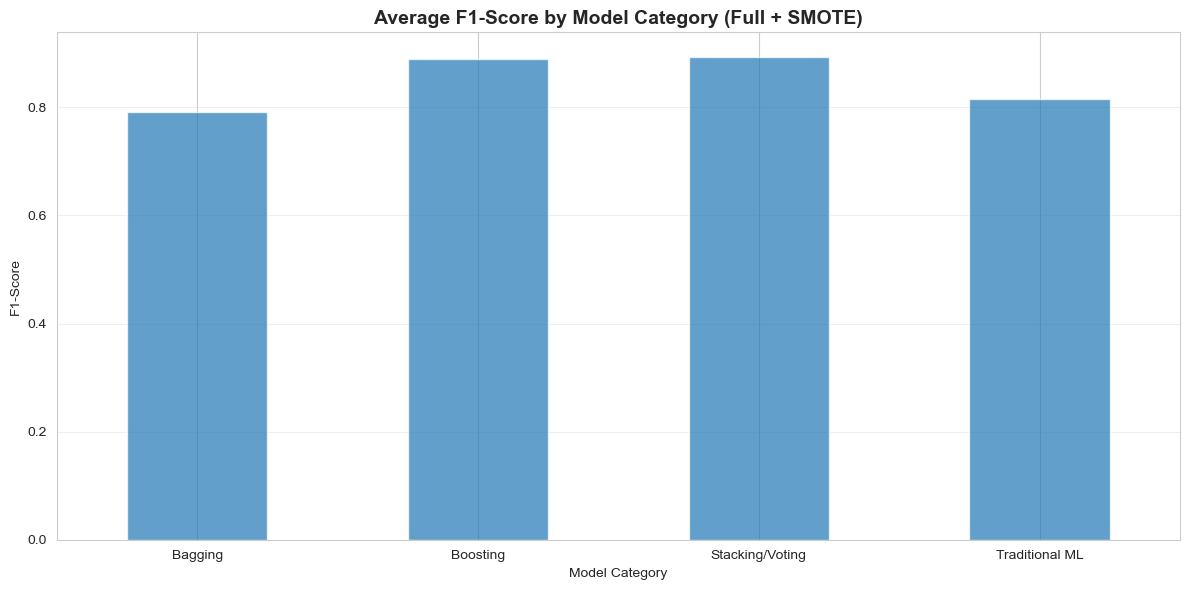

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def run_full_smote_pipeline(file_path):
    """
    Run OptimizedMLPipeline with Full Optimization + SMOTE only.
    Generates results for all model categories and saves comparison.
    """
    print(f"\n{'#'*80}")
    print("RUNNING FULL OPTIMIZATION + SMOTE PIPELINE")
    print(f"{'#'*80}\n")
    
    # Initialize pipeline with full optimization + SMOTE
    pipeline = OptimizedMLPipeline(
        file_path, 
        use_feature_selection=True, 
        use_pca=False, 
        use_smote=True
    )
    
    # Run all models
    pipeline.run_traditional_models()
    pipeline.run_bagging_models()
    pipeline.run_boosting_models()
    pipeline.run_stacking_voting_models()
    
    # Collect results
    results = []
    for result in pipeline.results:
        results.append({
            'Model': result['Model'],
            'Category': result['Category'],
            'F1-Score': result['F1-Score'],
            'AUC': result['AUC'],
            'Accuracy': result['Accuracy'],
            'Features': pipeline.X_train.shape[1]
        })
    
    comparison_df = pd.DataFrame(results)
    
    # Display summary
    print(f"\n{'='*80}")
    print("FULL + SMOTE STRATEGY RESULTS")
    print(f"{'='*80}\n")
    display_cols = ['Category', 'Model', 'F1-Score', 'AUC', 'Accuracy', 'Features']
    print(comparison_df[display_cols].sort_values('F1-Score', ascending=False).to_string(index=False))
    
    # Save results
    comparison_df.to_csv('full_smote_results.csv', index=False)
    print(f"\n✅ Full + SMOTE results saved to 'full_smote_results.csv'")
    
    # Visualization: F1-Score by Model Category
    fig, ax = plt.subplots(figsize=(12, 6))
    comparison_df.groupby('Category')['F1-Score'].mean().plot(kind='bar', ax=ax, alpha=0.7)
    
    ax.set_title('Average F1-Score by Model Category (Full + SMOTE)', fontsize=14, fontweight='bold')
    ax.set_ylabel('F1-Score')
    ax.set_xlabel('Model Category')
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig('full_smote_category_f1.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return comparison_df

# =======================
# MAIN EXECUTION
# =======================
if __name__ == "__main__":
    file_path = r"C:\Users\sodhi\Desktop\Design Project\combined\df_4.csv"
    full_smote_results = run_full_smote_pipeline(file_path)



################################################################################
RUNNING FULL OPTIMIZATION + SMOTE PIPELINE
################################################################################


OPTIMIZED ML PIPELINE (EDA-DRIVEN)
Configuration:
  • Feature Selection: True
  • PCA: False
  • SMOTE: True

📂 Loading dataset...
   ✅ Loaded: 704 rows, 21 columns
   ✅ Original class distribution: {0: 585, 1: 119}
   ✅ Imbalance ratio: 4.92:1

🔍 Removing multicollinear features (threshold=0.85)...
   Dropping features: ['rfc', 'ca', 'npm', 'loc', 'dam', 'mfa']
   Retained features: 14/20

📊 Applying log transformation to skewed features...
   ✓ Transformed: lcom
   ✓ Transformed: cbo
   ✓ Transformed: cbm
   ✓ Transformed: ce

🔄 Applying SMOTE (strategy=0.95)...
   Current ratio: 0.20
   ✅ After SMOTE: {0: 585, 1: 555}

⭐ Selecting top 12 features...
   Selected features:
    1. amc        (importance: 0.1237)
    2. ce         (importance: 0.1178)
    3. cam        (importance: 

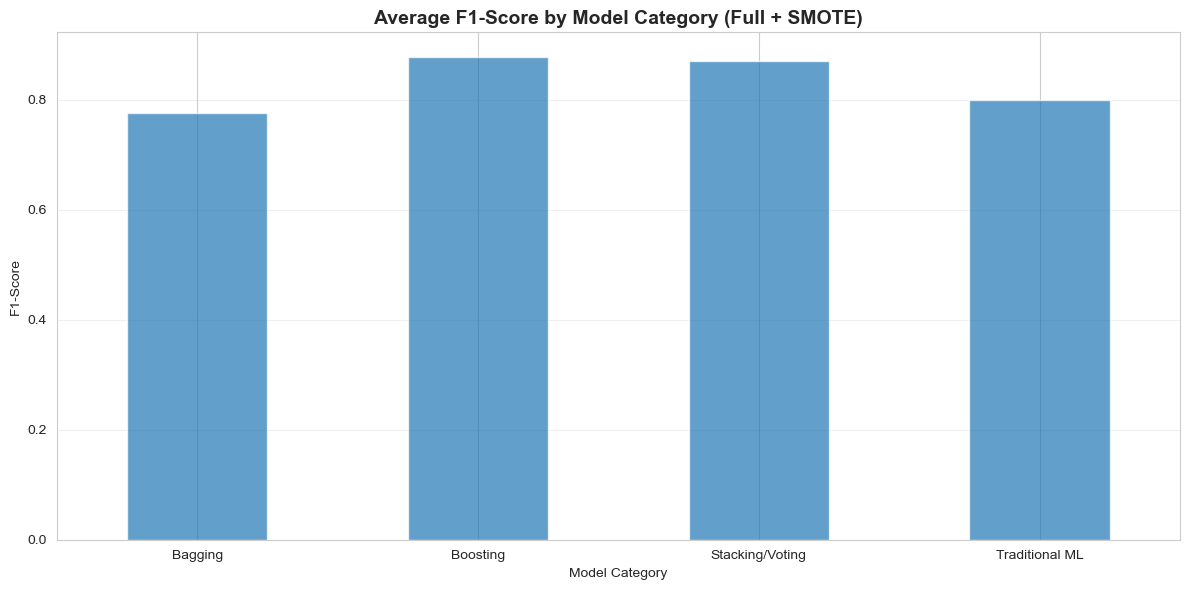

In [9]:
file_path = r"C:\Users\sodhi\Desktop\Design Project\combined\df_3.csv"
full_smote_results = run_full_smote_pipeline(file_path)


################################################################################
RUNNING FULL OPTIMIZATION + SMOTE PIPELINE
################################################################################


OPTIMIZED ML PIPELINE (EDA-DRIVEN)
Configuration:
  • Feature Selection: True
  • PCA: False
  • SMOTE: True

📂 Loading dataset...
   ✅ Loaded: 2784 rows, 21 columns
   ✅ Original class distribution: {0: 2222, 1: 562}
   ✅ Imbalance ratio: 3.95:1

🔍 Removing multicollinear features (threshold=0.85)...
   Dropping features: ['rfc', 'ca', 'npm', 'loc', 'dam']
   Retained features: 15/20

📊 Applying log transformation to skewed features...
   ✓ Transformed: lcom
   ✓ Transformed: cbo
   ✓ Transformed: cbm
   ✓ Transformed: ce

🔄 Applying SMOTE (strategy=0.95)...
   Current ratio: 0.25
   ✅ After SMOTE: {0: 2222, 1: 2110}

⭐ Selecting top 12 features...
   Selected features:
    1. cbo        (importance: 0.1405)
    2. ce         (importance: 0.1154)
    3. amc        (importance: 0.1

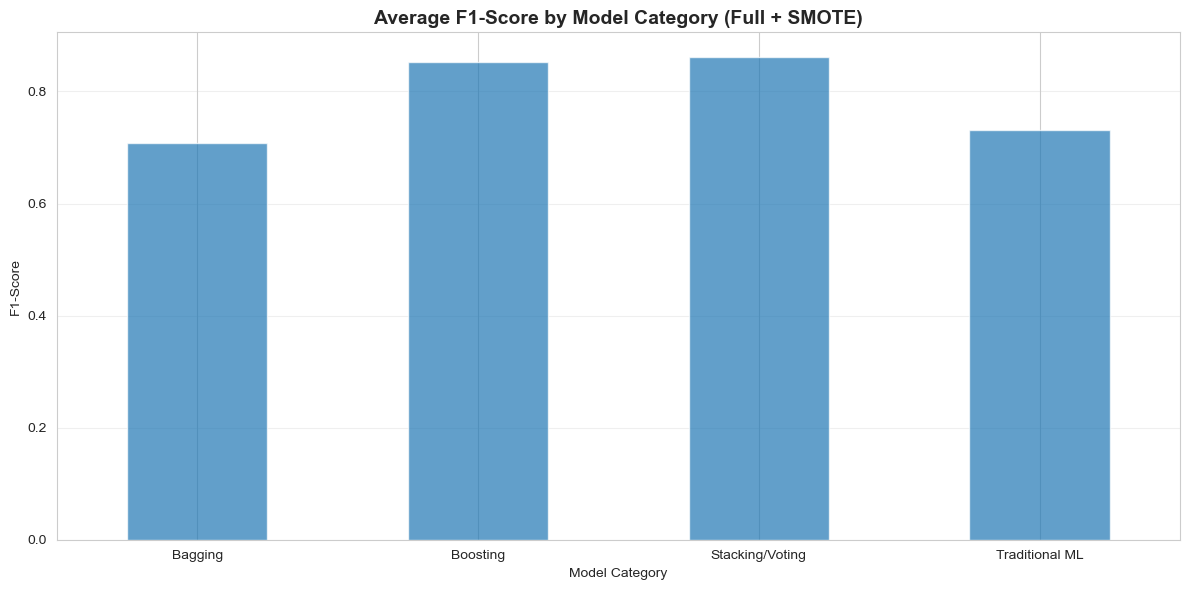

In [11]:
file_path = r"C:\Users\sodhi\Desktop\Design Project\combined\df_2.csv"
full_smote_results = run_full_smote_pipeline(file_path)


################################################################################
RUNNING FULL OPTIMIZATION + SMOTE PIPELINE
################################################################################


OPTIMIZED ML PIPELINE (EDA-DRIVEN)
Configuration:
  • Feature Selection: True
  • PCA: False
  • SMOTE: True

📂 Loading dataset...
   ✅ Loaded: 1692 rows, 21 columns
   ✅ Original class distribution: {0: 1342, 1: 350}
   ✅ Imbalance ratio: 3.83:1

🔍 Removing multicollinear features (threshold=0.85)...
   Dropping features: ['rfc', 'ca', 'npm']
   Retained features: 17/20

📊 Applying log transformation to skewed features...
   ✓ Transformed: lcom
   ✓ Transformed: cbo
   ✓ Transformed: cbm
   ✓ Transformed: ce

🔄 Applying SMOTE (strategy=0.95)...
   Current ratio: 0.26
   ✅ After SMOTE: {0: 1342, 1: 1274}

⭐ Selecting top 12 features...
   Selected features:
    1. loc        (importance: 0.1451)
    2. ce         (importance: 0.1067)
    3. lcom       (importance: 0.0937)
    4. ca

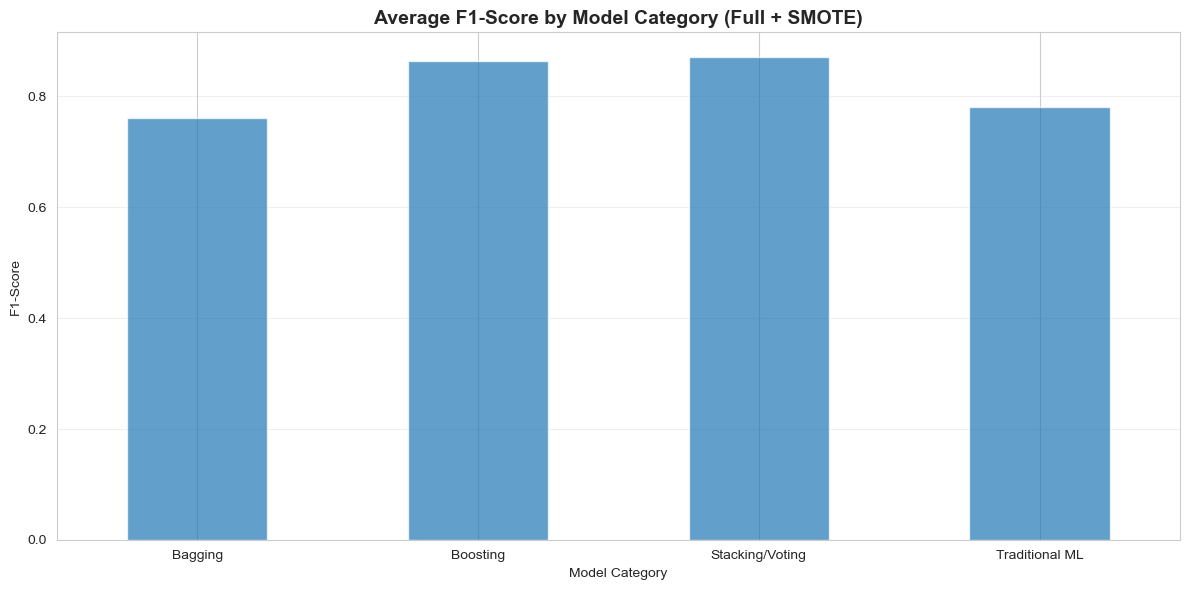

In [12]:
file_path = r"C:\Users\sodhi\Desktop\Design Project\combined\df_1.csv"
full_smote_results = run_full_smote_pipeline(file_path)


################################################################################
RUNNING FULL OPTIMIZATION + SMOTE PIPELINE
################################################################################


OPTIMIZED ML PIPELINE (EDA-DRIVEN)
Configuration:
  • Feature Selection: True
  • PCA: False
  • SMOTE: True

📂 Loading dataset...
   ✅ Loaded: 449 rows, 21 columns
   ✅ Original class distribution: {1: 260, 0: 189}
   ✅ Imbalance ratio: 1.38:1

🔍 Removing multicollinear features (threshold=0.85)...
   Dropping features: ['rfc', 'ca', 'loc', 'avg_cc']
   Retained features: 16/20

📊 Applying log transformation to skewed features...
   ✓ Transformed: lcom
   ✓ Transformed: cbo
   ✓ Transformed: cbm
   ✓ Transformed: npm
   ✓ Transformed: ce

🔄 Applying SMOTE (strategy=0.95)...
   Current ratio: 0.73
   ✅ After SMOTE: {1: 260, 0: 247}

⭐ Selecting top 12 features...
   Selected features:
    1. cbo        (importance: 0.1474)
    2. amc        (importance: 0.1204)
    3. wmc        (i

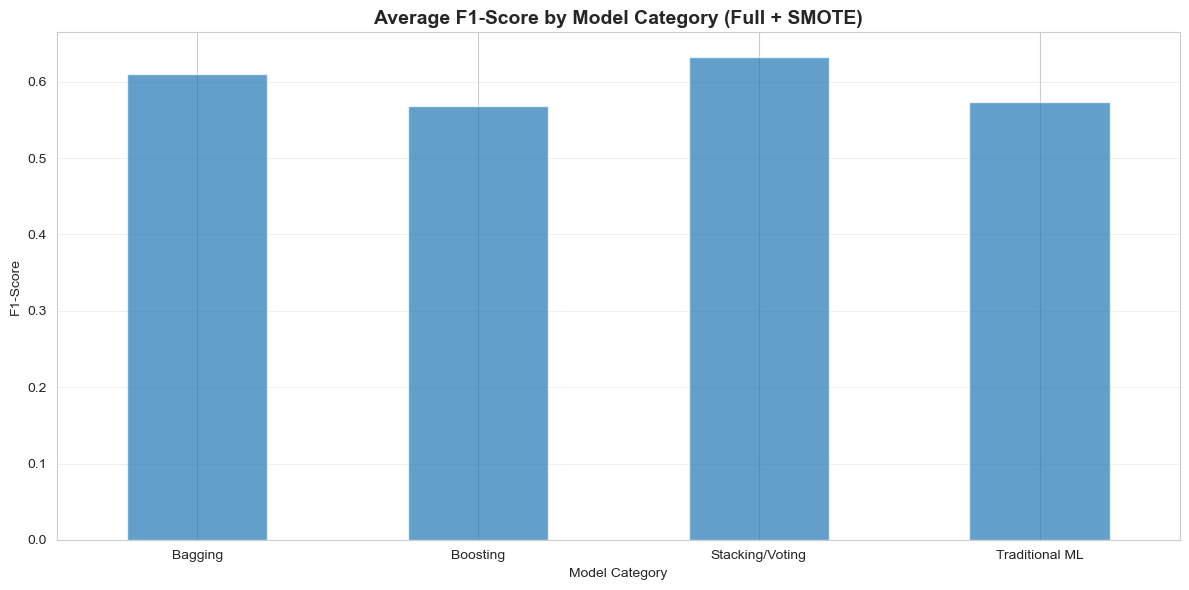

In [15]:
file_path = r"C:\Users\sodhi\Desktop\Design Project\combined\df_5.csv"
full_smote_results = run_full_smote_pipeline(file_path)